# Data Augmentation
Data augmentation is the process of creating new training images by applying random transformations such as flipping, rotating, zooming, or shifting the original images. It increases the diversity of the training data, reduces overfitting, and helps the model generalize better to unseen images.

## Padding
Padding is the process of adding extra pixels (usually zeros) around the border of an image before applying convolution. Its main purposes are: Preserve the size of the feature map after convolution, Retain edge information so border pixels are processed as effectively as center pixels, Allow deeper CNNs without the feature maps shrinking too quickly

## Stride
Stride is the number of pixels the convolution filter moves after each operation.

In [3]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 342.2 kB/s eta 0:02:08
   ---------------------------------------- 0.5/44.0 MB 342.2 kB/s eta 0:02:08
   ---------------------------------------- 0.5/44.0 MB 342.2 kB/s eta 0:02:08
   ---------------------------------------- 0.5/44.0 MB 342.2 kB/s eta 0:02:08
    --------------------------------------- 0.8/44.0 MB 338.9 kB/s eta 0:02:08
    --------------------------------------- 0


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [5]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 451s 2us/step


In [6]:
data_dir

'.\\datasets\\flower_photos'

In [13]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir = data_dir / "flower_photos"
data_dir

WindowsPath('datasets/flower_photos/flower_photos')

In [14]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [15]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [16]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

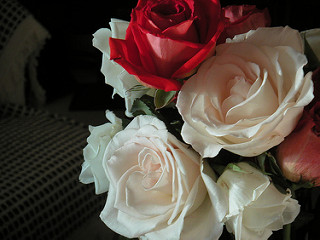

In [17]:
PIL.Image.open(str(roses[1]))

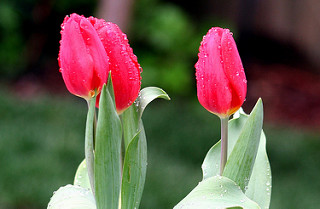

In [18]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [19]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [20]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [21]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [22]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [23]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [24]:
img.shape

(240, 179, 3)

In [25]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [26]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [27]:
X = np.array(X)
y = np.array(y)

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [29]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [30]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)              

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.4342 - loss: 1.3505
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 50s 581ms/step - accuracy: 0.6355 - loss: 0.9739
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.6911 - loss: 0.8020
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.7471 - loss: 0.6555
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.8318 - loss: 0.4656
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.9092 - loss: 0.2735
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.9386 - loss: 0.1855
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9666 - loss: 0.1087
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 271ms/step - accuracy: 0.9851 - loss: 0.0561
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 260ms/step - accuracy: 0.9920 - loss: 0.0476
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.9891 - loss: 0.0396
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step -

In [31]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6514 - loss: 2.5532


[2.5532474517822266, 0.6514161229133606]

In [32]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


array([[  5.5734515 ,  34.033627  ,  -3.4855833 ,  -1.3089939 ,
         -6.134614  ],
       [ 12.148573  ,   3.1384132 ,  -9.064816  ,  -7.638434  ,
          7.0337305 ],
       [ -5.0043416 ,   5.026703  ,  11.201757  , -10.740728  ,
          5.938509  ],
       ...,
       [ -2.6800966 ,  -7.873431  ,  -8.729054  ,  -0.56001383,
          1.2570584 ],
       [  6.376309  ,  12.303908  ,   1.704173  ,   3.3494158 ,
         -2.0697832 ],
       [ -4.373881  , -18.50195   ,  -0.2879084 ,   7.8635635 ,
          0.41072986]], shape=(918, 5), dtype=float32)

In [33]:
score = tf.nn.softmax(predictions[0])

In [34]:
np.argmax(score)

np.int64(1)

In [35]:
y_test[0]

np.int64(1)

In [39]:
img_height = 180
img_width = 180

data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

C:\Users\Diya Dholakia\OneDrive\Desktop\IITB\SOC\Week 3 - Deep Learning and CNN\.venv\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


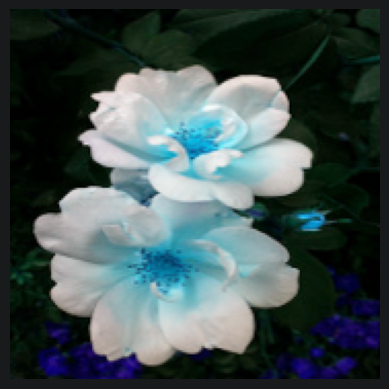

In [40]:
plt.axis('off')
plt.imshow(X[0])

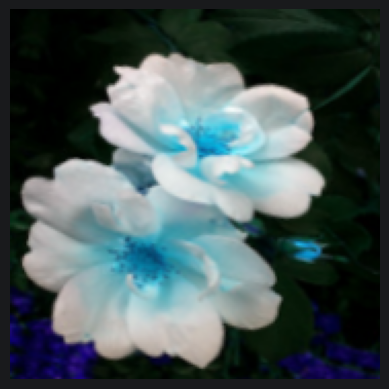

In [41]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

In [42]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 78s 807ms/step - accuracy: 0.3477 - loss: 1.5436
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 28s 315ms/step - accuracy: 0.5316 - loss: 1.1397
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.6134 - loss: 0.9999
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 305ms/step - accuracy: 0.6468 - loss: 0.9211
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 87s 831ms/step - accuracy: 0.6719 - loss: 0.8684
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 837ms/step - accuracy: 0.6831 - loss: 0.8352
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 334ms/step - accuracy: 0.7089 - loss: 0.7700
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.7213 - loss: 0.7524
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.7304 - loss: 0.6944
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.7515 - loss: 0.6617
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.7482 - loss: 0.6560
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s

In [43]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7473 - loss: 0.9164


[0.9164088368415833, 0.7472766637802124]